In [1]:
# Import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    RandomizedSearchCV
)

from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
    f1_score,
    precision_score,
    recall_score
)

from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.base import is_classifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import joblib
import os

sns.set_style("whitegrid")

import shap

c:\Users\ASUS\anaconda3\envs\dsai_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load the processed dataset
df = pd.read_csv("D:/ShaunakKathavate Github/digital_marketing_campaign_predictor/data/processed/processed_data.csv")

print("Shape:", df.shape)
df.head()

Shape: (8000, 35)


,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,...,x1_Referral,x1_SEO,x1_Social Media,x2_Awareness,x2_Consideration,x2_Conversion,x2_Retention,x3_IsConfid,x4_ToolConfid,Conversion
0,0.830400,1.391266,0.527784,-1.320998,-0.298267,-1.729507,-1.209000,-0.078303,-1.066014,-0.608829,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1
1,1.702775,-1.142380,-0.388643,0.010679,1.428427,1.205221,-1.010159,-0.562053,-1.550715,-1.309262,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1
2,0.159343,0.101011,-1.217996,1.460971,-0.509946,-1.589758,1.026327,1.435737,-1.723823,0.266712,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1
3,-0.780138,-1.080472,-1.573010,-0.205066,-0.298763,1.554594,-0.386987,1.647165,1.357493,-1.309262,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1
4,1.098823,-0.018599,-1.171591,1.167504,0.101230,-1.729507,-1.344153,1.482702,-1.516094,-0.608829,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1


In [3]:
# Split features and target
X = df.drop("Conversion", axis=1)
y = df["Conversion"]

In [4]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (6400, 34)
Test shape: (1600, 34)


In [5]:
# Handle class imbalance using scale_pos_weight
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
print("Scale Pos Weight:", scale_pos_weight)

Scale Pos Weight: 0.1408199643493761


In [6]:
# Stratified K-Fold Cross-Validation + OOF predictions for XGBoost
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_preds = np.zeros(len(X_train))

for train_idx, val_idx in skf.split(X_train, y_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model = XGBClassifier(
        eval_metric='auc',
        scale_pos_weight=scale_pos_weight,
        tree_method='hist',
        random_state=42
    )

    model.fit(X_tr, y_tr)
    oof_preds[val_idx] = model.predict_proba(X_val)[:,1]

print("OOF ROC-AUC:", roc_auc_score(y_train, oof_preds))

OOF ROC-AUC: 0.8119446512782329


In [7]:
# Hyperparameter tuning for XGBoost using RandomizedSearchCV
xgb_params = {
    "n_estimators": [300, 500],
    "max_depth": [4, 5, 6],
    "learning_rate": [0.01, 0.03],
    "subsample": [0.8],
    "colsample_bytree": [0.7, 0.8]
}

xgb_model = XGBClassifier(
    eval_metric='auc',
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

search = RandomizedSearchCV(
    xgb_model,
    param_distributions=xgb_params,
    n_iter=10,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)

best_xgb = XGBClassifier(
    **search.best_params_,
    eval_metric='auc',
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    tree_method='hist'
)

best_xgb.fit(X_train, y_train)

# 🔥 IMPORTANT FIX: Refit to ensure clean sklearn classifier
best_xgb = XGBClassifier(**search.best_params_)
best_xgb.fit(X_train, y_train)

print("Best XGB Score:", search.best_score_)
print("Best Params:", search.best_params_)

c:\Users\ASUS\anaconda3\envs\dsai_env\lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


Best XGB Score: nan
Best Params: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.03, 'colsample_bytree': 0.7}


In [8]:
# Train LightGBM
lgb_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8
)

lgb_model.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 5610, number of negative: 790
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002269 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3948
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.876563 -> initscore=1.960273
[LightGBM] [Info] Start training from score 1.960273
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,5
,learning_rate,0.03
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [9]:
# Verify Cllassifier
print("XGB is classifier:", is_classifier(best_xgb))
print("LGB is classifier:", is_classifier(lgb_model))

XGB is classifier: False
LGB is classifier: True


In [11]:
print(type(best_xgb))

<class 'xgboost.sklearn.XGBClassifier'>


In [12]:
print(is_classifier(best_xgb))

False


In [10]:
# Create an ensemble of XGBoost, Random Forest, and LightGBM
ensemble = VotingClassifier(
    estimators=[
        ('xgb', best_xgb),
        ('rf', RandomForestClassifier(n_estimators=300, random_state=42)),
        ('lgb', lgb_model)
    ],
    voting='soft'
)

ensemble.fit(X_train, y_train)

ValueError: The estimator XGBClassifier should be a classifier.

In [ ]:
# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000)

cv_scores = cross_val_score(lr, X_train, y_train, cv=cv, scoring='roc_auc')

print("Logistic Regression CV ROC-AUC:", np.mean(cv_scores))

Logistic Regression CV ROC-AUC: 0.7942654392021481


In [ ]:
# Random Forest
rf = RandomForestClassifier(random_state=42)

cv_scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring='roc_auc')

print("Random Forest CV ROC-AUC:", np.mean(cv_scores))

Random Forest CV ROC-AUC: 0.8151458742300143


In [ ]:
# XGBoost
xgb_model = xgb.XGBClassifier(eval_metric='logloss', random_state=42)

cv_scores = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring='roc_auc')

print("XGBoost CV ROC-AUC:", np.mean(cv_scores))

c:\Users\ASUS\anaconda3\envs\dsai_env\lib\site-packages\sklearn\model_selection\_validation.py:971: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\ASUS\anaconda3\envs\dsai_env\lib\site-packages\sklearn\metrics\_scorer.py", line 152, in __call__
    score = scorer._score(
  File "c:\Users\ASUS\anaconda3\envs\dsai_env\lib\site-packages\sklearn\metrics\_scorer.py", line 400, in _score
    y_pred = method_caller(
  File "c:\Users\ASUS\anaconda3\envs\dsai_env\lib\site-packages\sklearn\metrics\_scorer.py", line 90, in _cached_call
    result, _ = _get_response_values(
  File "c:\Users\ASUS\anaconda3\envs\dsai_env\lib\site-packages\sklearn\utils\_response.py", line 235, in _get_response_values
    raise ValueError(
ValueError: XGBClassifier should either be a classifier to be used with response_method=predict_proba or the response_method should be 'predict'. Got a regres

XGBoost CV ROC-AUC: nan


c:\Users\ASUS\anaconda3\envs\dsai_env\lib\site-packages\sklearn\model_selection\_validation.py:971: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\ASUS\anaconda3\envs\dsai_env\lib\site-packages\sklearn\metrics\_scorer.py", line 152, in __call__
    score = scorer._score(
  File "c:\Users\ASUS\anaconda3\envs\dsai_env\lib\site-packages\sklearn\metrics\_scorer.py", line 400, in _score
    y_pred = method_caller(
  File "c:\Users\ASUS\anaconda3\envs\dsai_env\lib\site-packages\sklearn\metrics\_scorer.py", line 90, in _cached_call
    result, _ = _get_response_values(
  File "c:\Users\ASUS\anaconda3\envs\dsai_env\lib\site-packages\sklearn\utils\_response.py", line 235, in _get_response_values
    raise ValueError(
ValueError: XGBClassifier should either be a classifier to be used with response_method=predict_proba or the response_method should be 'predict'. Got a regres

In [ ]:
# Hyperparameter tuning for Random Forest
rf_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [4, 6, 8, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

rf_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=rf_params,
    n_iter=20,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

rf_random.fit(X_train, y_train)

print("Best RF Params:", rf_random.best_params_)
print("Best RF Score:", rf_random.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best RF Params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 8}
Best RF Score: 0.8243676526997451


In [ ]:
# Hyperparameter tuning for XGBoost
xgb_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

xgb_random = RandomizedSearchCV(
    estimator=xgb.XGBClassifier(eval_metric='logloss', random_state=42),
    param_distributions=xgb_params,
    n_iter=20,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

xgb_random.fit(X_train, y_train)

print("Best XGB Params:", xgb_random.best_params_)
print("Best XGB Score:", xgb_random.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


c:\Users\ASUS\anaconda3\envs\dsai_env\lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan]
  warnings.warn(


Best XGB Params: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
Best XGB Score: nan


In [ ]:
# Choose best model
best_model = xgb_random.best_estimator_

best_model.fit(X_train, y_train)

,objective,'binary:logistic'
,use_label_encoder,None
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [ ]:
# Evaluate on test set
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.84      0.19      0.31       198
           1       0.90      1.00      0.94      1402

    accuracy                           0.90      1600
   macro avg       0.87      0.59      0.62      1600
weighted avg       0.89      0.90      0.86      1600

ROC-AUC: 0.8159951872505367


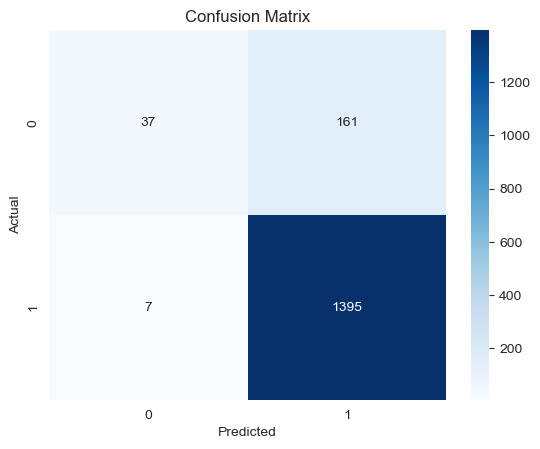

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

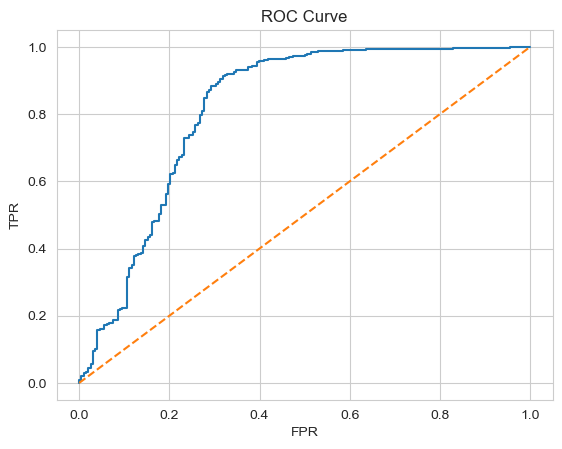

In [ ]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

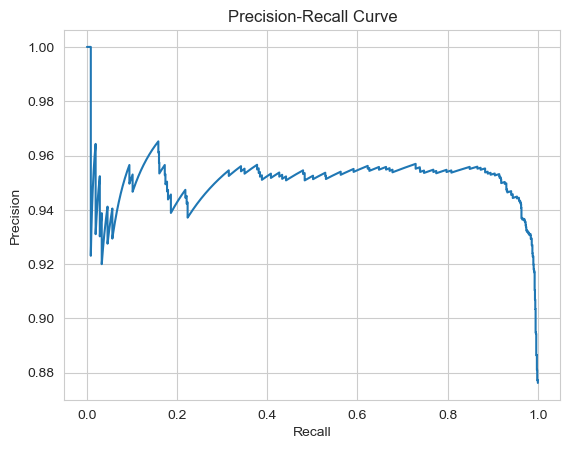

In [ ]:
# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

In [ ]:
os.makedirs("D:/ShaunakKathavate Github/digital_marketing_campaign_predictor/models", exist_ok=True)

joblib.dump(best_model, "D:/ShaunakKathavate Github/digital_marketing_campaign_predictor/models/xgb_random_bfm.pkl")

print("✅ Model saved successfully!")

✅ Model saved successfully!


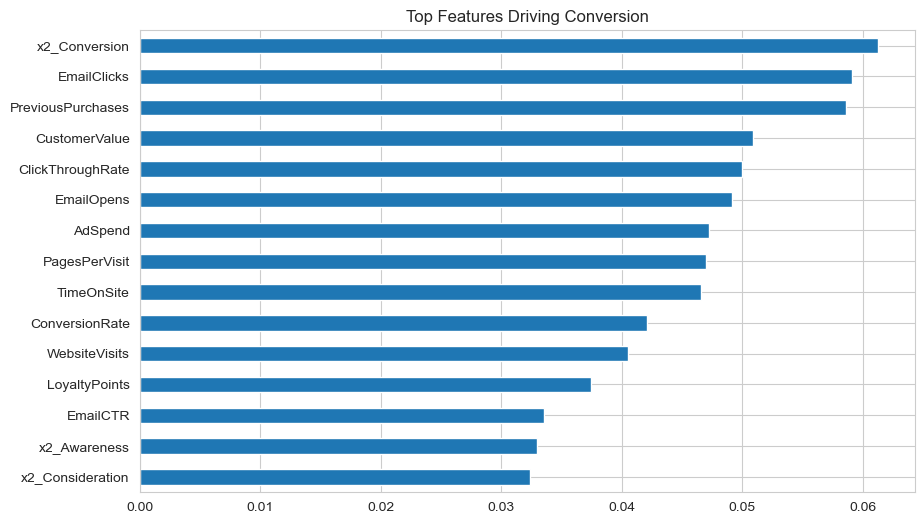

In [ ]:
# Feature Importance
importances = best_model.feature_importances_

feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_imp.head(15).plot(kind='barh')
plt.title("Top Features Driving Conversion")
plt.gca().invert_yaxis()
plt.show()

# Threshold Tuning

In [ ]:
# Threshold Analysis
y_prob = best_model.predict_proba(X_test)[:,1]

thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)

    precision = precision_score(y_test, y_pred_t)
    recall = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)

    results.append([t, precision, recall, f1])

results_df = pd.DataFrame(results, columns=["Threshold", "Precision", "Recall", "F1"])
print(results_df)

    Threshold  Precision    Recall        F1
0        0.10   0.876798  1.000000  0.934355
1        0.15   0.877270  0.999287  0.934311
2        0.20   0.878845  0.998573  0.934891
3        0.25   0.879950  0.998573  0.935516
4        0.30   0.882093  0.997860  0.936412
5        0.35   0.883765  0.997860  0.937353
6        0.40   0.884883  0.997860  0.937982
7        0.45   0.891512  0.996434  0.941058
8        0.50   0.896530  0.995007  0.943205
9        0.55   0.906372  0.994294  0.948299
10       0.60   0.915789  0.992867  0.952772
11       0.65   0.924000  0.988588  0.955203
12       0.70   0.932019  0.977889  0.954403
13       0.75   0.943781  0.957917  0.950796
14       0.80   0.951220  0.917974  0.934301
15       0.85   0.955321  0.838802  0.893278


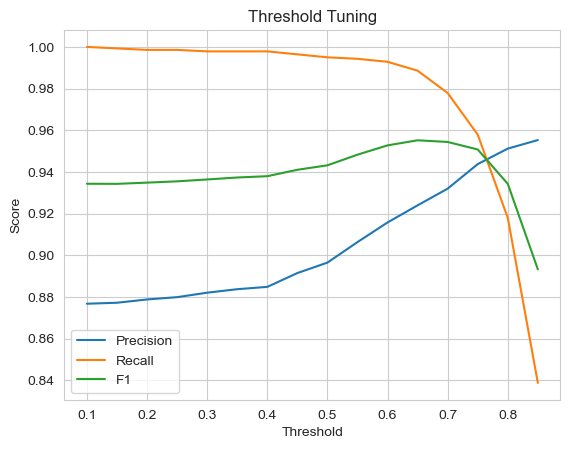

In [ ]:
# Plotting threshold tuning results
plt.plot(results_df["Threshold"], results_df["Precision"], label="Precision")
plt.plot(results_df["Threshold"], results_df["Recall"], label="Recall")
plt.plot(results_df["Threshold"], results_df["F1"], label="F1")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning")
plt.legend()
plt.show()

In [ ]:
# Threshold selection
optimal_threshold = 0.75

y_pred_final = (y_prob >= optimal_threshold).astype(int)

# COST-BASED OPTIMIZATION

In [ ]:
# Example business assumptions
profit_per_conversion = 100
cost_per_contact = 10

In [ ]:
def calculate_profit(y_true, y_pred):
    tp = ((y_true == 1) & (y_pred == 1)).sum()
    fp = ((y_true == 0) & (y_pred == 1)).sum()

    profit = (tp * profit_per_conversion) - (fp * cost_per_contact)
    return profit

In [ ]:
profits = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    profit = calculate_profit(y_test, y_pred_t)
    profits.append(profit)

results_df["Profit"] = profits
print(results_df.sort_values("Profit", ascending=False).head())

   Threshold  Precision    Recall        F1  Profit
0       0.10   0.876798  1.000000  0.934355  138230
1       0.15   0.877270  0.999287  0.934311  138140
3       0.25   0.879950  0.998573  0.935516  138090
6       0.40   0.884883  0.997860  0.937982  138080
2       0.20   0.878845  0.998573  0.934891  138070


# SHAP EXPLAINABILITY

In [ ]:
# SHAP Values for explainability
explainer = shap.TreeExplainer(best_model.get_booster())
shap_values = explainer.shap_values(X_test)

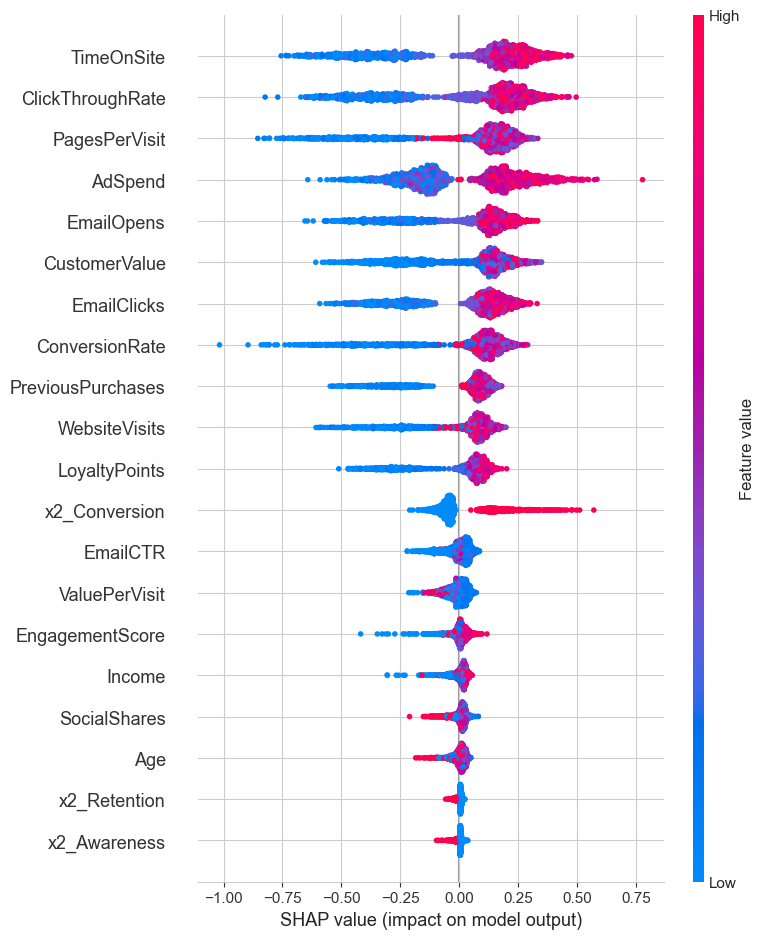

In [ ]:
# Global feature importance
shap.summary_plot(shap_values, X_test)

In [ ]:
# Local explanation for a single prediction
shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0]
)

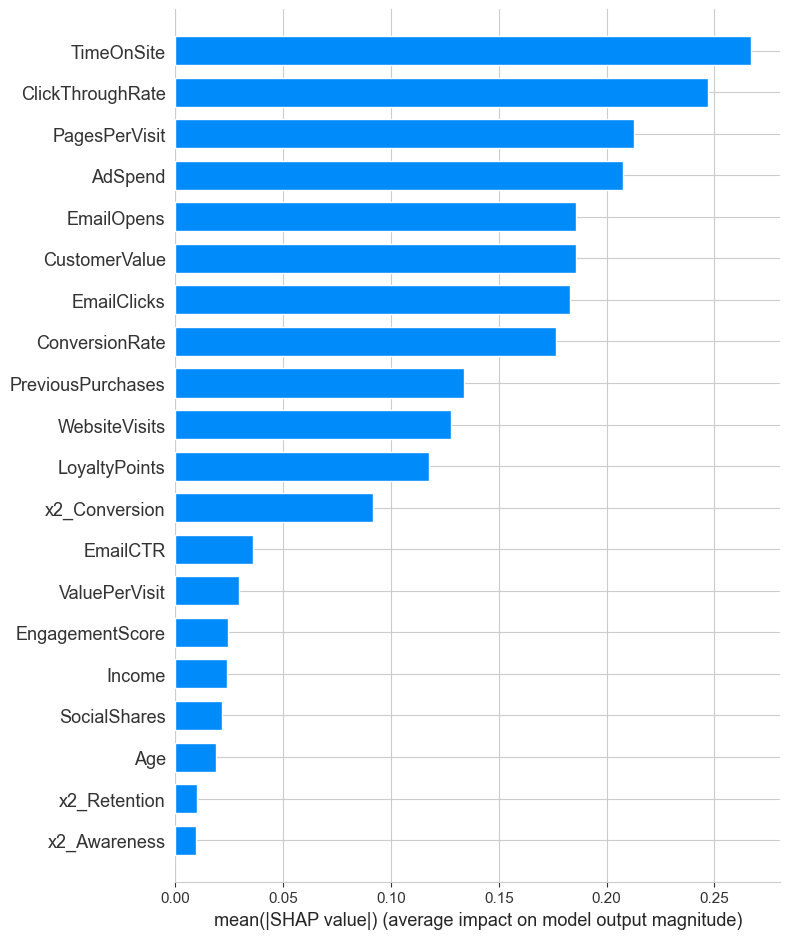

In [ ]:
# SHAP summary plot for feature importance
shap.summary_plot(shap_values, X_test, plot_type="bar")